# Notebook 04 — Portfolio Greeks and P&L Attribution

Computes delta, gamma, vega, vanna, and volga for a sample SPX options
portfolio using the FNO surrogate and finite-difference bumps.
Then runs a full Taylor-expansion P&L attribution for a market shock.

**Runtime estimate:** 2–5 min

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

from greeks.portfolio_greeks import (
    bs_greeks, fno_surface_greeks, portfolio_greeks,
    MATURITIES, STRIKES
)
from greeks.pnl_attribution import pnl_attribution
from fno_model import MirrorPaddedFNO2d
from normalizers import ParameterNormalizer, IVSurfaceNormalizer
from calibrate import _load_normalizers


Device: cuda


## 1. Load Model

In [2]:
model = MirrorPaddedFNO2d(param_dim=6).to(DEVICE)
model.load_state_dict(torch.load(
    "../artifacts/weights/fno_v3_final_prod.pth", map_location=DEVICE))
model.eval()
_load_normalizers("v3")
import calibrate as _cal
pn = _cal._param_norm
yn = _cal._iv_norm
print("Model ready")


Model ready


## 2. Black-Scholes Greeks Reference

In [3]:
S, K, T, r, sigma = 100.0, 100.0, 0.5, 0.05, 0.20
g = bs_greeks(S, K, T, r, sigma)
print("Black-Scholes Greeks (ATM, T=0.5yr, σ=20%)")
for name, val in g.items():
    print(f"  {name:8s} = {val:.6f}")


Black-Scholes Greeks (ATM, T=0.5yr, σ=20%)
  price    = 6.888729
  delta    = 0.597734
  gamma    = 0.027359
  vega     = 27.358659
  theta    = -8.115968
  rho      = 26.442359
  vanna    = -0.205190
  volga    = 3.590824
  speed    = -0.000752
  zomma    = -0.133202
  ultima   = -67.070393


## 3. FNO Greeks Surface

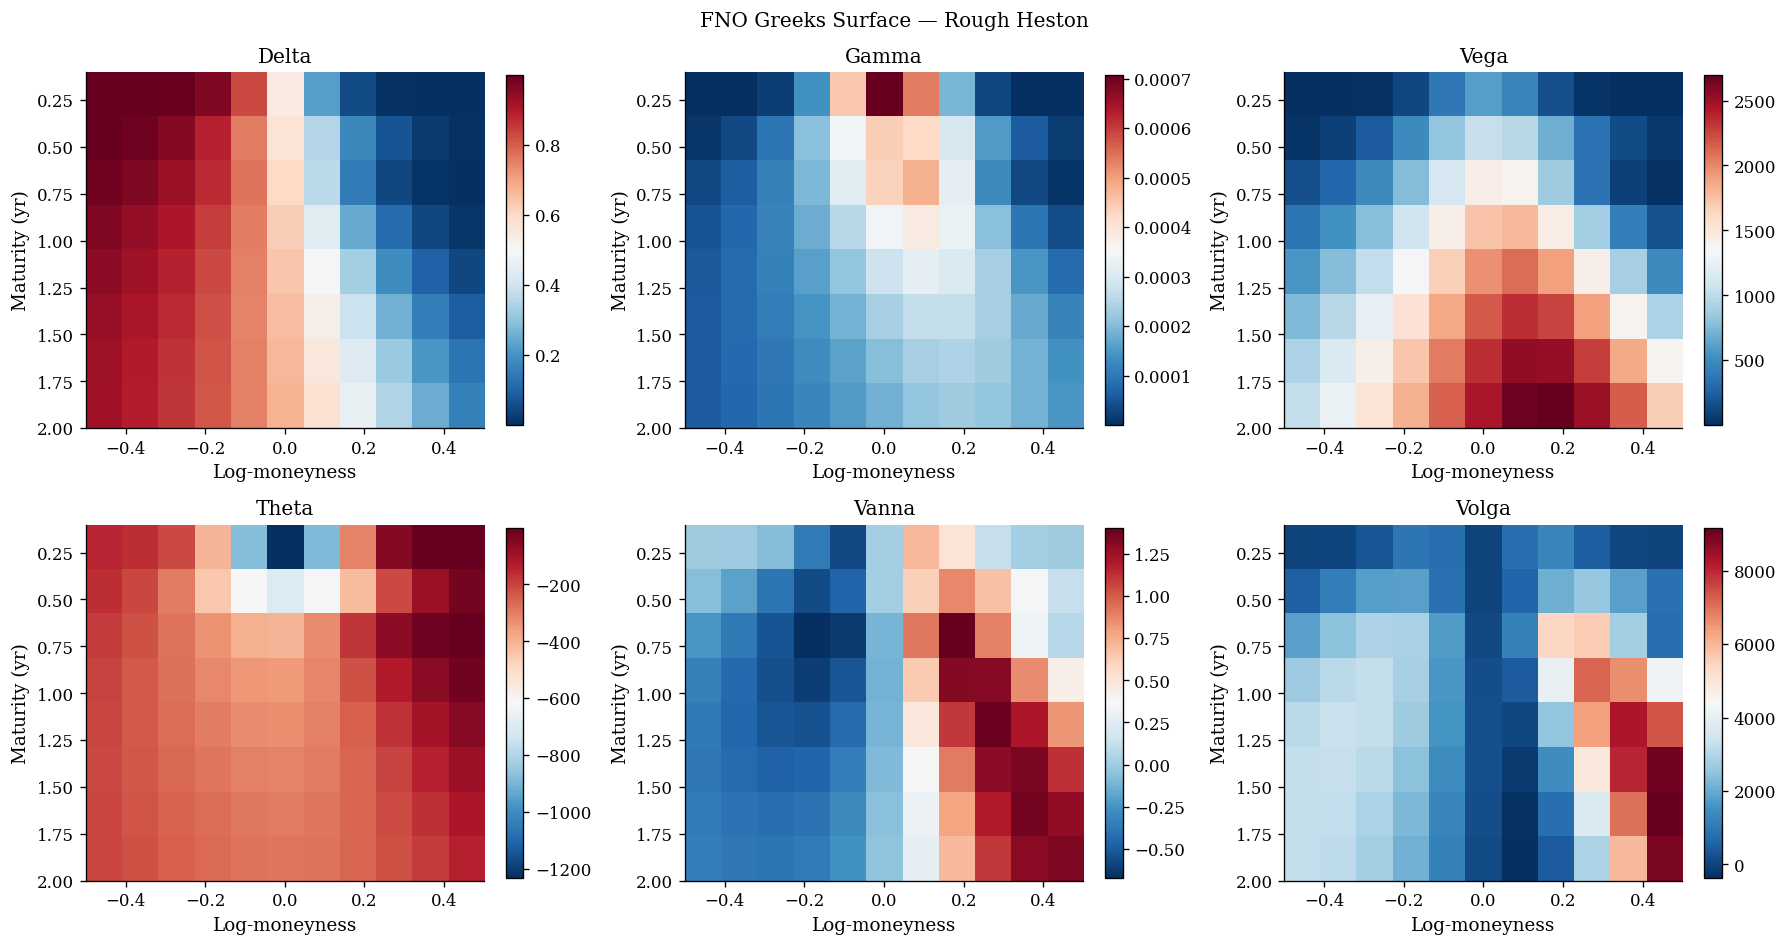

In [4]:
# Calibrated Rough Heston parameters for 2024-01-02
theta = np.array([2.0, 0.04, 0.5, -0.7, 0.04, 0.10], dtype=np.float32)
greeks_surface = fno_surface_greeks(model, theta, pn, yn, S=4800.0)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
greek_names = ["delta", "gamma", "vega", "theta", "vanna", "volga"]
K_abs = np.exp(STRIKES)
T_mesh, K_mesh = np.meshgrid(MATURITIES, K_abs, indexing="ij")

for ax, name in zip(axes.flat, greek_names):
    if name not in greeks_surface:
        ax.set_visible(False); continue
    data = greeks_surface[name]
    im = ax.imshow(data, aspect="auto", cmap="RdBu_r",
                   extent=[STRIKES[0], STRIKES[-1], MATURITIES[-1], MATURITIES[0]])
    ax.set_title(name.capitalize())
    ax.set_xlabel("Log-moneyness"); ax.set_ylabel("Maturity (yr)")
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.suptitle("FNO Greeks Surface — Rough Heston")
plt.tight_layout(); plt.show()


## 4. Portfolio Greeks

In [5]:
S_spot = 4800.0
positions = [
    {"K": 4800.0, "T": 0.5,  "type": "call", "quantity":  10.0, "notional": 100.0},
    {"K": 4700.0, "T": 0.5,  "type": "put",  "quantity": -20.0, "notional": 100.0},
    {"K": 4900.0, "T": 1.0,  "type": "call", "quantity":   5.0, "notional": 100.0},
    {"K": 4500.0, "T": 1.5,  "type": "put",  "quantity":  15.0, "notional": 100.0},
    {"K": 5000.0, "T": 0.25, "type": "call", "quantity":  -8.0, "notional": 100.0},
]
port_greeks = portfolio_greeks(positions, model, theta, pn, yn, S=S_spot)

print("Portfolio Greeks")
print(f"  Total Delta : {port_greeks['total_delta']:+.4f}")
print(f"  Total Gamma : {port_greeks['total_gamma']:+.6f}")
vega_total = port_greeks.get('vega_bucket', np.zeros(8)).sum()
# vega_bucket is $/unit-vol (per 1.0 = 100% vol change); divide by 100 for $/1%-vol
print(f"  Total Vega  : {vega_total/100:+.2f}  ($ per 1% vol move)")
print(f"  Total Vanna : {port_greeks['total_vanna']:+.4f}")
print(f"  Total Volga : {port_greeks['total_volga']/1e6:+.3f}M  ($ per unit-vol² × notional)")
print(f"  Hedge (ES contracts): {port_greeks.get('hedge_contracts', 'N/A')}")


Portfolio Greeks
  Total Delta : +828.3013
  Total Gamma : -0.296197
  Total Vega  : +19012.39  ($ per 1% vol move)
  Total Vanna : -322.4237
  Total Volga : +1.003M  ($ per unit-vol² × notional)
  Hedge (ES contracts): -17


## 5. Vega Bucket (by Maturity)

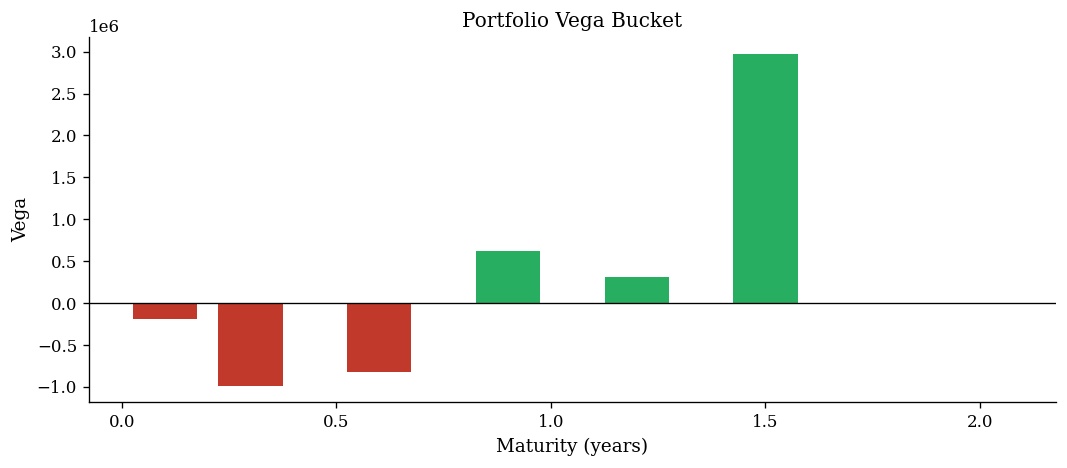

In [6]:
vega_bucket = port_greeks.get("vega_bucket", np.zeros(8))
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in vega_bucket]
ax.bar(MATURITIES, vega_bucket, width=0.15, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Maturity (years)"); ax.set_ylabel("Vega")
ax.set_title("Portfolio Vega Bucket")
plt.tight_layout(); plt.show()


## 6. P&L Attribution — Market Shock

Simulate a -1% spot move and +1 vol point shift.

In [7]:
d_iv = np.full((8, 11), 0.01)   # uniform +1% vol shift (d_sigma = 0.01)

# pnl_attribution reads greeks from position dicts.
# Positions above have no greek values → enrich each with BS greeks
# interpolated from the FNO-predicted IV surface.
from greeks.portfolio_greeks import MATURITIES, STRIKES
iv_surf = greeks_surface['iv_surface']   # (8, 11) from fno_surface_greeks

enriched = []
for pos in positions:
    k_pos = np.log(pos['K'] / S_spot)
    t_idx = int(np.argmin(np.abs(np.array(MATURITIES) - pos['T'])))
    k_idx = int(np.argmin(np.abs(np.array(STRIKES) - k_pos)))
    sigma_pos = float(iv_surf[t_idx, k_idx])
    g = bs_greeks(S_spot, pos['K'], pos['T'], 0.05, sigma_pos,
                  option_type=pos['type'])
    enriched.append({**pos,
                     'delta': g['delta'], 'gamma': g['gamma'],
                     'vega':  g['vega'],  'vanna': g['vanna'],
                     'volga': g['volga']})

result = pnl_attribution(
    portfolio=enriched,
    dS=-48.0,                   # -1% of 4800
    d_iv_surface=d_iv,
    S=S_spot,
)
components = result["breakdown"]  # {delta_pnl, gamma_pnl, vega_pnl, vanna_pnl, volga_pnl}
total = result.get("explained_pnl", sum(components.values()))
print("P&L Attribution (dS=-48, dvol=+1%)")
max_abs = max((abs(v) for v in components.values()), default=1) or 1
for name, val in components.items():
    bar = "#" * int(abs(val) / max_abs * 30 + 1)
    print(f"  {name:15s} = {val:+10.2f}  {bar}")
print(f"  {'Total':15s} = {total:+10.2f}")


P&L Attribution (dS=-48, dvol=+1%)
  delta_pnl       =  -38945.01  ###############################
  gamma_pnl       =    -427.04  #
  vega_pnl        =  +19311.21  ###############
  vanna_pnl       =     +63.93  #
  volga_pnl       =     +61.27  #
  Total           =  -19935.64


## 7. Waterfall Chart

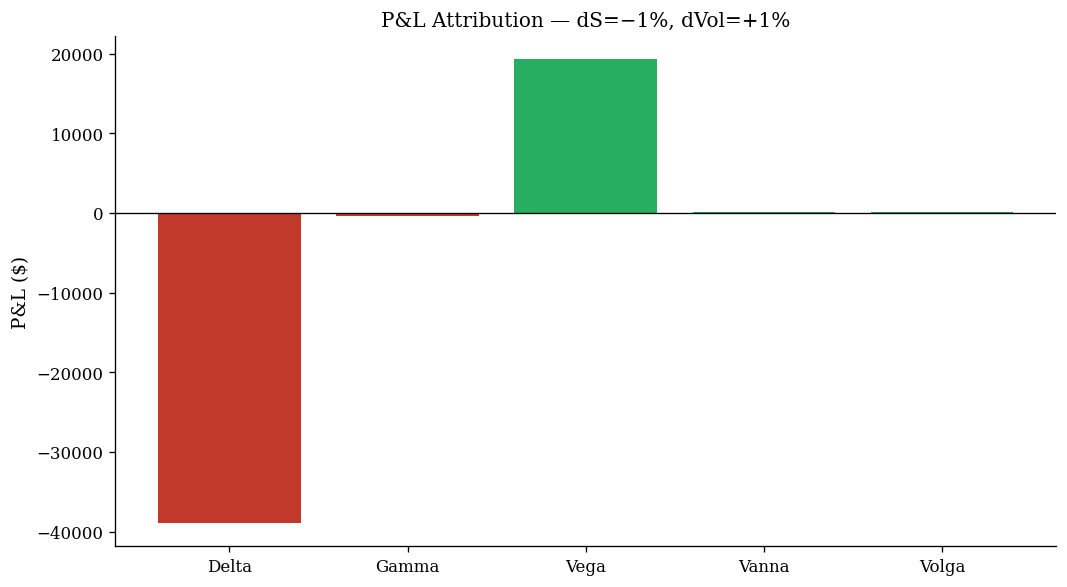

In [8]:
labels = list(components.keys())
vals   = [components[k] for k in labels]
labels_clean = [l.replace("_pnl","").capitalize() for l in labels]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#27ae60" if v >= 0 else "#c0392b" for v in vals]
ax.bar(labels_clean, vals, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("P&L ($)")
ax.set_title("P&L Attribution — dS=−1%, dVol=+1%")
plt.tight_layout(); plt.show()
